In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, Activation , LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error , r2_score
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

df = pd.read_csv('/content/T1_cleaned.csv')
df = df.set_index('Date/Time')
df["WindSpeed_sq"] = df["Wind Speed (m/s)"]**2
df["WindSpeed_cube"] = df["Wind Speed (m/s)"]**3
df.index = pd.to_datetime(df.index)
df.head()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),hour,day_of_week,month,day_of_year,wind_direction_sin,wind_direction_cos,power_deviation,WindSpeed_sq,WindSpeed_cube
Date/Time,,,,,,,,,,,,,
2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,0.0,0.0,1.0,1.0,-0.984792,-0.173736,-36.281117,28.210291,149.834333
2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,0.0,0.0,1.0,1.0,-0.999719,-0.023715,-66.148316,32.173476,182.493326
2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,0.0,0.0,1.0,1.0,-0.998998,0.044749,-84.523429,27.207040,141.912921
2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,0.0,0.0,1.0,1.0,-0.999759,0.021956,-96.481664,32.031912,181.290183
2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,0.0,0.0,1.0,1.0,-0.997151,-0.075426,-111.052276,31.113425,173.548848


In [ ]:
df.sample()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),hour,day_of_week,month,day_of_year,wind_direction_sin,wind_direction_cos,power_deviation,WindSpeed_sq,WindSpeed_cube
Date/Time,,,,,,,,,,,,,
2018-04-20 08:50:00,1830.428955,8.418664,1778.080768,31.907499,8.0,4.0,4.0,110.0,0.528549,0.848903,52.348187,70.873903,596.663576


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
X = df.drop(['LV ActivePower (kW)'], axis=1)
y = df['LV ActivePower (kW)']

print(X.shape)
print(y.shape)

(35562, 12)
(35562,)


In [ ]:
df.loc['2018-08-01 00:00:00']

,2018-08-01
LV ActivePower (kW),1096.728027
Wind Speed (m/s),7.578811
Theoretical_Power_Curve (KWh),1298.820474
Wind Direction (°),71.827698
hour,0.000000
day_of_week,2.000000
month,8.000000
day_of_year,213.000000
wind_direction_sin,0.950123
wind_direction_cos,0.311876


In [ ]:
df.to_csv('processed_data.csv')

In [ ]:
train_end ='2018-08-01 00:00:00'
val_end = '2018-10-01 00:00:00'
test_end = '2018-12-01 00:00:00'

X_train_raw = X.loc[:train_end]
X_val_raw   = X.loc[train_end:val_end]
X_test_raw  = X.loc[val_end:]

y_train_raw = y.loc[:train_end]
y_val_raw   = y.loc[train_end:val_end]
y_test_raw  = y.loc[val_end:]

In [ ]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_val_scaled   = scaler_X.transform(X_val_raw)
X_test_scaled  = scaler_X.transform(X_test_raw)

y_train_scaled = scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1))
y_val_scaled   = scaler_y.transform(y_val_raw.values.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test_raw.values.reshape(-1, 1))

In [ ]:
# Sliding Window
def create_sequences(X, y, look_back=24):
    Xs, ys = [], []
    for i in range(len(X) - look_back):
        Xs.append(X[i : i + look_back])
        ys.append(y[i + look_back])
    return np.array(Xs), np.array(ys)

LOOK_BACK = 144

In [ ]:
X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, LOOK_BACK)
X_val,   y_val   = create_sequences(X_val_scaled,   y_val_scaled,   LOOK_BACK)
X_test,  y_test  = create_sequences(X_test_scaled,  y_test_scaled,  LOOK_BACK)

print(X_train.shape)
print(y_train.shape)

(29632, 144, 12)
(29632, 1)


In [ ]:
model = Sequential([
    LSTM(64 , input_shape=X_train.shape[1:] , return_sequences=True, kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    LSTM(32 , return_sequences=False, kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    Dense(64 , activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss= Huber(), metrics=['mae'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 144, 64)        │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 144, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,305 (134.00 KB)

 Trainable params: 34,305 (134.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,  # يرجع لأحسن weights تلقائي
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    # يحفظ أحسن موديل
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0642 - mae: 0.1246
Epoch 1: val_loss improved from None to 0.01236, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
463/463 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0337 - mae: 0.0962 - val_loss: 0.0124 - val_mae: 0.0871 - learning_rate: 0.0010
Epoch 2/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0111 - mae: 0.0765
Epoch 2: val_loss improved from 0.01236 to 0.00751, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
463/463 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.0099 - mae: 0.0736 - val_loss: 0.0075 - val_mae: 0.0696 - learning_rate: 0.0010
Epoch 3/100
460/463 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0074 - mae: 0.0666
Epoch 3: val_loss improved from 0.00751 to 0.00583, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
463/463 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0074 - mae: 0.0670 - val_l

In [ ]:
best_model = load_model('best_model.keras')
# التنبؤ
y_pred_scaled = best_model.predict(X_test)

# ارجع للقيم الأصلية
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# ━━━━━━━━━━━━━━━━━━━━━━━━━━
# Metrics Functions
# ━━━━━━━━━━━━━━━━━━━━━━━━━━
def smape(actual, predicted):
    numerator   = np.abs(actual - predicted)
    denominator = (np.abs(actual) + np.abs(predicted)) / 2
    mask = denominator != 0
    return np.mean(numerator[mask] / denominator[mask]) * 100

def mape_nonzero(actual, predicted, threshold=10):
    mask = actual > threshold
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

# ━━━━━━━━━━━━━━━━━━━━━━━━━━
# حساب الـ Metrics
# ━━━━━━━━━━━━━━━━━━━━━━━━━━
mae   = mean_absolute_error(y_true, y_pred)
rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
r2    = r2_score(y_true, y_pred)
smape_val = smape(y_true, y_pred)
mape_val  = mape_nonzero(y_true, y_pred, threshold=10)

print("=" * 35)
print(f"MAE:         {mae:.2f} kW")
print(f"RMSE:        {rmse:.2f} kW")
print(f"SMAPE:       {smape_val:.2f}%")
print(f"MAPE:        {mape_val:.2f}%")
print(f"R²:          {r2:.4f}")
print(f"Mean Actual: {y_true.mean():.2f} kW")
print(f"MAE/Mean:    {mae/y_true.mean()*100:.2f}%")
print("=" * 35)

381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MAE:         155.12 kW
RMSE:        243.31 kW
SMAPE:       52.41%
MAPE:        19.74%
R²:          0.9658
Mean Actual: 1485.08 kW
MAE/Mean:    10.44%


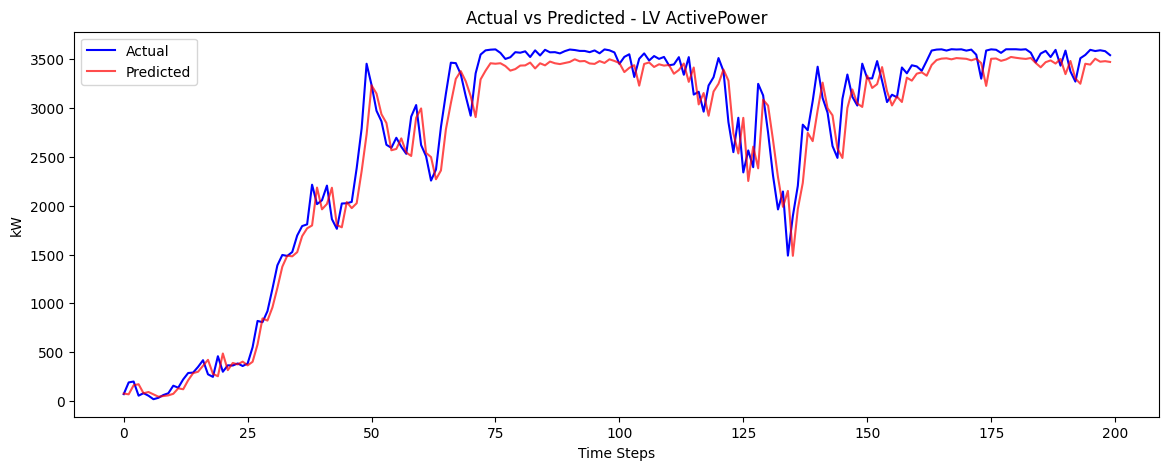

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(y_true[:200], label='Actual',    color='blue')
plt.plot(y_pred[:200], label='Predicted', color='red', alpha=0.7)
plt.title('Actual vs Predicted - LV ActivePower')
plt.xlabel('Time Steps')
plt.ylabel('kW')
plt.legend()
plt.show()

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━
# اختاري sample عشوائية من الـ test
# ━━━━━━━━━━━━━━━━━━━━━━━━━━
sample_idx = np.random.randint(0, len(X_test))
sample_X   = X_test[sample_idx : sample_idx + 1]   # (1, look_back, features)

sample_pred_scaled = best_model.predict(sample_X)
sample_pred = scaler_y.inverse_transform(sample_pred_scaled)[0][0]
sample_true = scaler_y.inverse_transform(y_test[sample_idx].reshape(1, -1))[0][0]

print(f"Sample Index: {sample_idx}")
print(f"Actual:       {sample_true:.2f} kW")
print(f"Predicted:    {sample_pred:.2f} kW")
print(f"Error:        {abs(sample_true - sample_pred):.2f} kW")
print(f"Error %:      {abs(sample_true - sample_pred) / (sample_true + 1e-8) * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Sample Index: 2194
Actual:       0.00 kW
Predicted:    39.60 kW
Error:        39.60 kW
Error %:      395991096496.58%


In [ ]:
import joblib

# Save the scaler_X object to a file named 'scaler_X.pkl'
joblib.dump(scaler_X, 'scaler_X.pkl')

best_model.save("/content/best_model.keras")      # Google Colab
# Load the scaler object from the file 'scaler_X.pkl'
# The first argument to joblib.load should be the file path (string), not the scaler object itself.
loaded_scaler_X = joblib.load('scaler_X.pkl')